🚀 Assignment 1
AI-Powered Employee Attrition Prediction System
Kaggle Dataset
🏆 IBM HR Analytics Employee Attrition & Performance
Kaggle:
 https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

Real Business Problem
An organization loses employees every month.
HR wants to predict:
Which employees are likely to leave
Why they may leave
Which factors influence attrition
Risk category of employees

Student Deliverables
Phase 1 — EDA
Identify:
Attrition rate
Department-wise attrition
Gender-wise attrition
Salary impact
Experience impact

Phase 2 — Machine Learning
Logistic Regression
Predict:
Attrition = Yes / No

Decision Tree
Generate HR decision rules.
Example:
IF
JobSatisfaction < 2
AND
MonthlyIncome < 4000

THEN
High Attrition Risk

Random Forest
Build production model.

SVM
Compare accuracy.

KNN
Find similar employees.

Naive Bayes
Probability-based prediction.

PCA
Dimensionality reduction.

K-Means
Employee Segmentation:
Cluster 1:
High Performers

Cluster 2:
At Risk

Cluster 3:
New Employees

AWS Requirements
S3
Store:
dataset/
model/
reports/

SageMaker
Train:
logistic_regression.pkl
random_forest.pkl

Endpoint
Deploy:
employee-attrition-predictor

Lambda
Input:
{
 "Age": 35,
 "MonthlyIncome": 4500,
 "JobSatisfaction": 2
}

API Gateway
POST /predict

Output
{
 "attrition_probability": 87.3,
 "risk_level": "HIGH"
}


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Path to dataset files: /kaggle/input/ibm-hr-analytics-attrition-dataset


In [4]:
import pandas as pd
import os

# Check files in dataset folder
print(os.listdir(path))

['WA_Fn-UseC_-HR-Employee-Attrition.csv']


In [5]:
# Find CSV file
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

csv_file = os.path.join(path, csv_files[0])

df = pd.read_csv(csv_file)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Phase 1 - Exploratory Data Analysis (EDA)

#### Attrition Rate

In [6]:
# Calculate the attrition rate
attrition_counts = df['Attrition'].value_counts()
attrition_rate = (attrition_counts['Yes'] / df.shape[0]) * 100

print(f"Total employees: {df.shape[0]}")
print(f"Number of employees who attritted (Yes): {attrition_counts['Yes']}")
print(f"Number of employees who did not attrit (No): {attrition_counts['No']}")
print(f"Attrition Rate: {attrition_rate:.2f}%")

Total employees: 1470
Number of employees who attritted (Yes): 237
Number of employees who did not attrit (No): 1233
Attrition Rate: 16.12%


#### Department-wise Attrition

Department-wise Attrition Rates:


Attrition,No,Yes,Total,Attrition_Rate
Department,,,,
Sales,354,92,446,20.627803
Human Resources,51,12,63,19.047619
Research & Development,828,133,961,13.839750


/tmp/ipykernel_7201/2967628131.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_attrition.index, y=dept_attrition['Attrition_Rate'], palette='viridis')


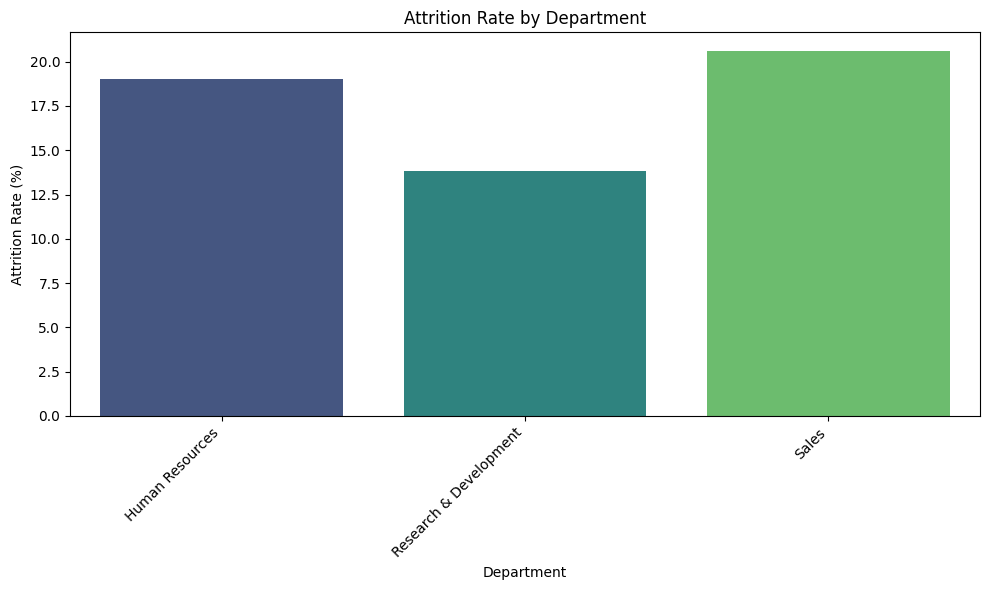

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate department-wise attrition
dept_attrition = df.groupby(['Department', 'Attrition']).size().unstack(fill_value=0)
dept_attrition['Total'] = dept_attrition['No'] + dept_attrition['Yes']
dept_attrition['Attrition_Rate'] = (dept_attrition['Yes'] / dept_attrition['Total']) * 100

print("Department-wise Attrition Rates:")
display(dept_attrition.sort_values(by='Attrition_Rate', ascending=False))

# Visualize department-wise attrition rate
plt.figure(figsize=(10, 6))
sns.barplot(x=dept_attrition.index, y=dept_attrition['Attrition_Rate'], palette='viridis')
plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Gender-wise Attrition

Gender-wise Attrition Rates:


Attrition,No,Yes,Total,Attrition_Rate
Gender,,,,
Male,732,150,882,17.006803
Female,501,87,588,14.795918


/tmp/ipykernel_7201/458846371.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_attrition.index, y=gender_attrition['Attrition_Rate'], palette='pastel')


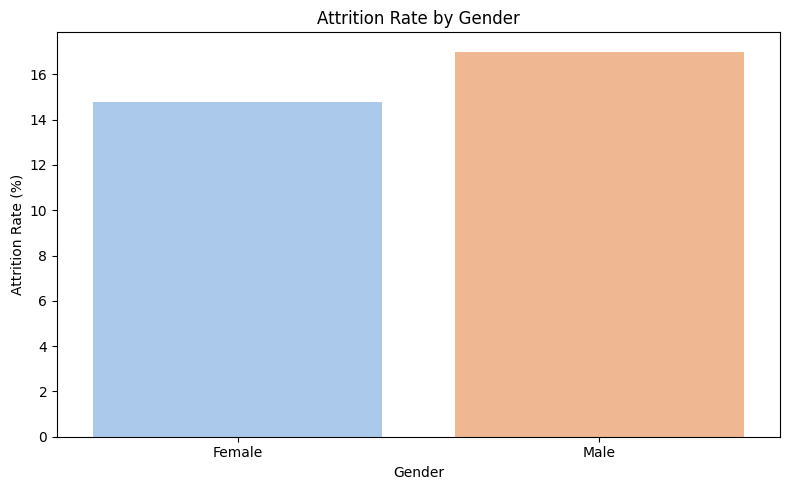

In [8]:
# Calculate gender-wise attrition
gender_attrition = df.groupby(['Gender', 'Attrition']).size().unstack(fill_value=0)
gender_attrition['Total'] = gender_attrition['No'] + gender_attrition['Yes']
gender_attrition['Attrition_Rate'] = (gender_attrition['Yes'] / gender_attrition['Total']) * 100

print("Gender-wise Attrition Rates:")
display(gender_attrition.sort_values(by='Attrition_Rate', ascending=False))

# Visualize gender-wise attrition rate
plt.figure(figsize=(8, 5))
sns.barplot(x=gender_attrition.index, y=gender_attrition['Attrition_Rate'], palette='pastel')
plt.title('Attrition Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

#### Salary Impact on Attrition

Attrition Rates by Monthly Income Bins:


Attrition,No,Yes,Total,Attrition_Rate
MonthlyIncome_bins,,,,
0,557,157,714,21.988796
1,355,44,399,11.027569
2,140,26,166,15.662651
3,65,5,70,7.142857
4,116,5,121,4.132231


/tmp/ipykernel_7201/1732919230.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=salary_attrition.index, y=salary_attrition['Attrition_Rate'], palette='coolwarm')


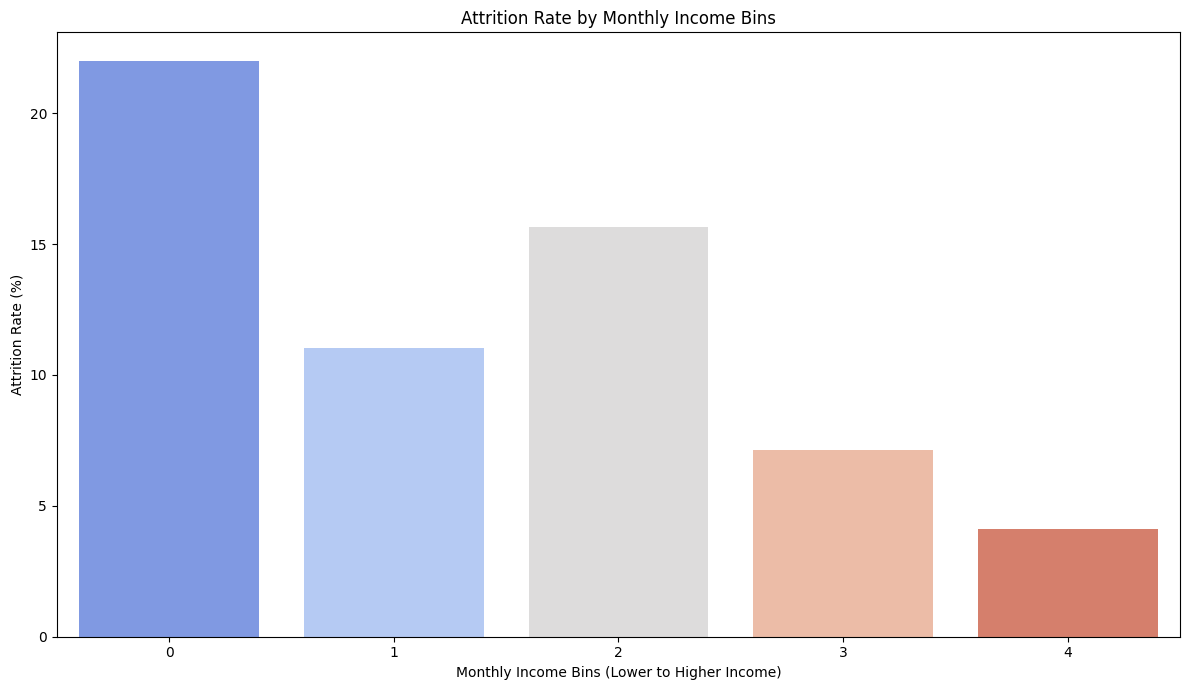


Attrition Rates by Job Level:


Attrition,No,Yes,Total,Attrition_Rate
JobLevel,,,,
1,400,143,543,26.335175
3,186,32,218,14.678899
2,482,52,534,9.737828
5,64,5,69,7.246377
4,101,5,106,4.716981


/tmp/ipykernel_7201/1732919230.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_level_attrition.index, y=job_level_attrition['Attrition_Rate'], palette='plasma')


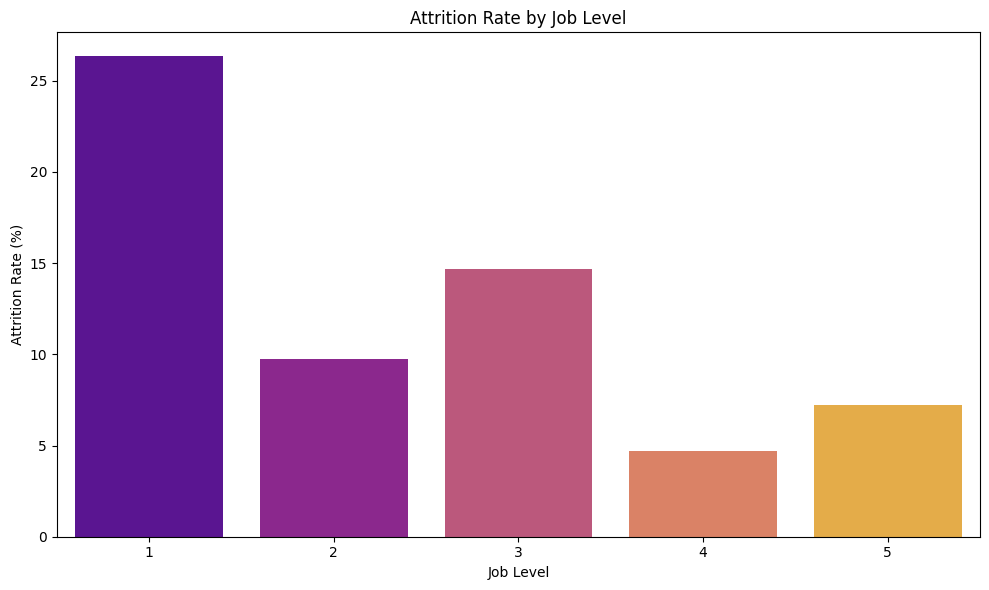

In [9]:
# Calculate attrition rate by MonthlyIncome bins
df['MonthlyIncome_bins'] = pd.cut(df['MonthlyIncome'], bins=5, labels=False)
salary_attrition = df.groupby(['MonthlyIncome_bins', 'Attrition']).size().unstack(fill_value=0)
salary_attrition['Total'] = salary_attrition['No'] + salary_attrition['Yes']
salary_attrition['Attrition_Rate'] = (salary_attrition['Yes'] / salary_attrition['Total']) * 100

print("Attrition Rates by Monthly Income Bins:")
display(salary_attrition)

# Visualize salary impact on attrition
plt.figure(figsize=(12, 7))
sns.barplot(x=salary_attrition.index, y=salary_attrition['Attrition_Rate'], palette='coolwarm')
plt.title('Attrition Rate by Monthly Income Bins')
plt.xlabel('Monthly Income Bins (Lower to Higher Income)')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Also consider Job Level impact, as it's often correlated with salary
job_level_attrition = df.groupby(['JobLevel', 'Attrition']).size().unstack(fill_value=0)
job_level_attrition['Total'] = job_level_attrition['No'] + job_level_attrition['Yes']
job_level_attrition['Attrition_Rate'] = (job_level_attrition['Yes'] / job_level_attrition['Total']) * 100

print("\nAttrition Rates by Job Level:")
display(job_level_attrition.sort_values(by='Attrition_Rate', ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(x=job_level_attrition.index, y=job_level_attrition['Attrition_Rate'], palette='plasma')
plt.title('Attrition Rate by Job Level')
plt.xlabel('Job Level')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

#### Experience Impact on Attrition

Attrition Rates by Total Working Years Bins:


Attrition,No,Yes,Total,Attrition_Rate
TotalWorkingYears_bins,,,,
0,478,147,625,23.520000
1,464,62,526,11.787072
2,187,20,207,9.661836
3,80,4,84,4.761905
4,24,4,28,14.285714


/tmp/ipykernel_7201/3535542035.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=experience_attrition.index, y=experience_attrition['Attrition_Rate'], palette='mako')


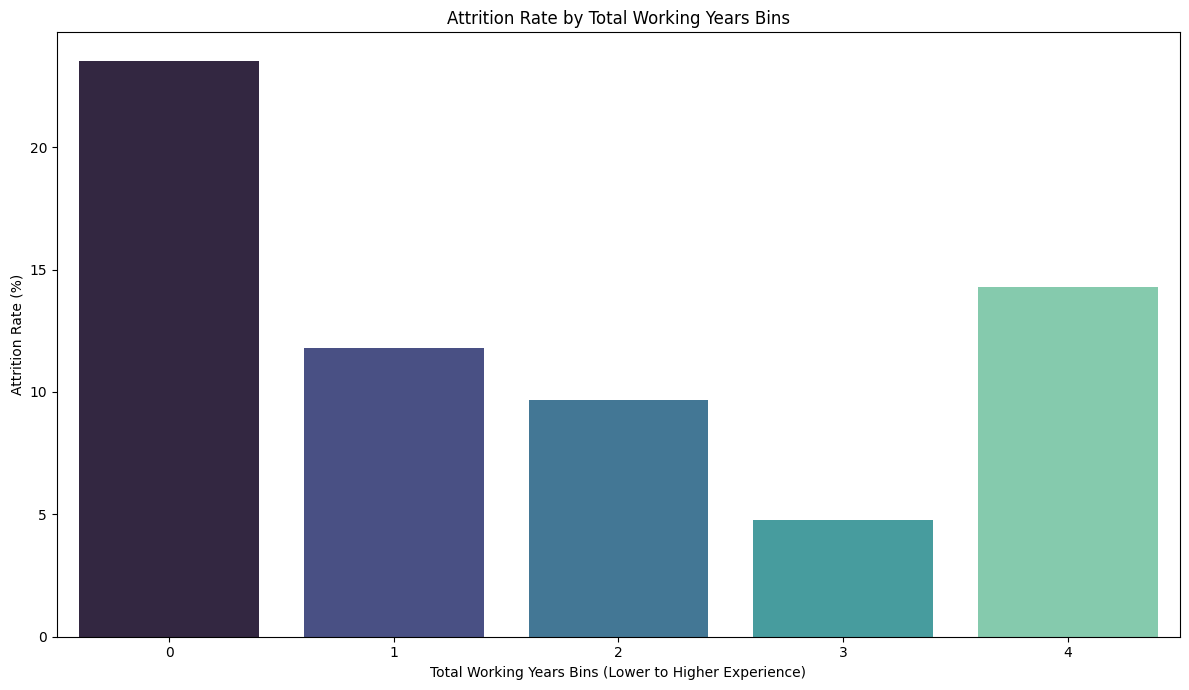


Attrition Rates by Years At Company:


Attrition,No,Yes,Total,Attrition_Rate
YearsAtCompany,,,,
40,0,1,1,100.000000
23,1,1,2,50.000000
0,28,16,44,36.363636
1,112,59,171,34.502924
32,2,1,3,33.333333
31,2,1,3,33.333333
2,100,27,127,21.259843
33,4,1,5,20.000000
4,91,19,110,17.272727


/tmp/ipykernel_7201/3535542035.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=years_at_company_attrition.index, y=years_at_company_attrition['Attrition_Rate'], palette='rocket')


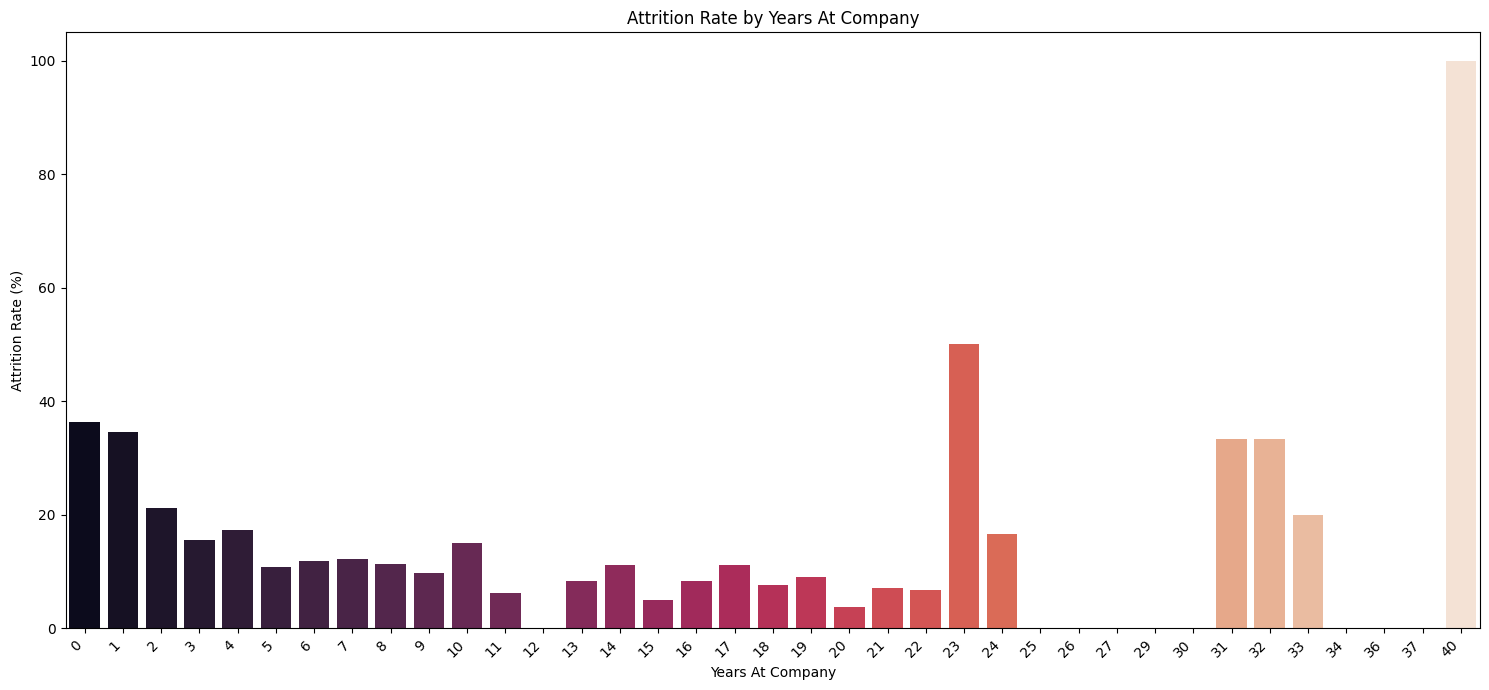

In [10]:
# Calculate attrition rate by TotalWorkingYears bins
df['TotalWorkingYears_bins'] = pd.cut(df['TotalWorkingYears'], bins=5, labels=False)
experience_attrition = df.groupby(['TotalWorkingYears_bins', 'Attrition']).size().unstack(fill_value=0)
experience_attrition['Total'] = experience_attrition['No'] + experience_attrition['Yes']
experience_attrition['Attrition_Rate'] = (experience_attrition['Yes'] / experience_attrition['Total']) * 100

print("Attrition Rates by Total Working Years Bins:")
display(experience_attrition)

# Visualize experience impact on attrition
plt.figure(figsize=(12, 7))
sns.barplot(x=experience_attrition.index, y=experience_attrition['Attrition_Rate'], palette='mako')
plt.title('Attrition Rate by Total Working Years Bins')
plt.xlabel('Total Working Years Bins (Lower to Higher Experience)')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Also consider YearsAtCompany impact
years_at_company_attrition = df.groupby(['YearsAtCompany', 'Attrition']).size().unstack(fill_value=0)
years_at_company_attrition['Total'] = years_at_company_attrition['No'] + years_at_company_attrition['Yes']
years_at_company_attrition['Attrition_Rate'] = (years_at_company_attrition['Yes'] / years_at_company_attrition['Total']) * 100

print("\nAttrition Rates by Years At Company:")
display(years_at_company_attrition.sort_values(by='Attrition_Rate', ascending=False).head(10)) # Display top 10

plt.figure(figsize=(15, 7))
sns.barplot(x=years_at_company_attrition.index, y=years_at_company_attrition['Attrition_Rate'], palette='rocket')
plt.title('Attrition Rate by Years At Company')
plt.xlabel('Years At Company')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Phase 2 - Machine Learning

#### Logistic Regression

#### Data Preprocessing for Machine Learning

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Drop unnecessary columns that were created for EDA visualization
df_ml = df.drop(columns=['MonthlyIncome_bins', 'TotalWorkingYears_bins']).copy()

# Separate target variable
X = df_ml.drop('Attrition', axis=1)
y = df_ml['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0) # Convert 'Yes'/'No' to 1/0

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data preprocessing complete. Training and testing sets created.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data preprocessing complete. Training and testing sets created.
X_train shape: (1176, 34)
X_test shape: (294, 34)
y_train shape: (1176,)
y_test shape: (294,)


#### Logistic Regression Model Training

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Create a pipeline that first preprocesses the data and then applies Logistic Regression
logistic_regression_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# Train the model
logistic_regression_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


#### Logistic Regression Model Evaluation

In [13]:
# Make predictions on the test set
y_pred_lr = logistic_regression_pipeline.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
print(f"\nAccuracy Score: {accuracy_score(y_test, y_pred_lr):.4f}")

Confusion Matrix:
[[237  10]
 [ 31  16]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294


Accuracy Score: 0.8605


#### Random Forest Model (Production Model)

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Create a pipeline that first preprocesses the data and then applies Random Forest
random_forest_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train the model
random_forest_pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


#### Random Forest Model Evaluation

In [16]:
# Make predictions on the test set
y_pred_rf = random_forest_pipeline.predict(X_test)

# Evaluate the model
print("Confusion Matrix (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))
print(f"\nAccuracy Score (Random Forest): {accuracy_score(y_test, y_pred_rf):.4f}")

Confusion Matrix (Random Forest):
[[242   5]
 [ 40   7]]

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.86      0.98      0.91       247
           1       0.58      0.15      0.24        47

    accuracy                           0.85       294
   macro avg       0.72      0.56      0.58       294
weighted avg       0.81      0.85      0.81       294


Accuracy Score (Random Forest): 0.8469


#### Support Vector Machine (SVM)

In [17]:
from sklearn.svm import SVC

# Create a pipeline that first preprocesses the data and then applies SVM
svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42))
])

# Train the model
svm_pipeline.fit(X_train, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


#### Support Vector Machine (SVM) Evaluation

In [18]:
# Make predictions on the test set
y_pred_svm = svm_pipeline.predict(X_test)

# Evaluate the model
print("Confusion Matrix (SVM):")
print(confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report (SVM):")
print(classification_report(y_test, y_pred_svm))
print(f"\nAccuracy Score (SVM): {accuracy_score(y_test, y_pred_svm):.4f}")

Confusion Matrix (SVM):
[[244   3]
 [ 37  10]]

Classification Report (SVM):
              precision    recall  f1-score   support

           0       0.87      0.99      0.92       247
           1       0.77      0.21      0.33        47

    accuracy                           0.86       294
   macro avg       0.82      0.60      0.63       294
weighted avg       0.85      0.86      0.83       294


Accuracy Score (SVM): 0.8639


#### K-Nearest Neighbors (KNN)

In [19]:
from sklearn.neighbors import KNeighborsClassifier

# Create a pipeline that first preprocesses the data and then applies KNN
# Using n_neighbors=5 as a common starting point
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

# Train the model
knn_pipeline.fit(X_train, y_train)

print("KNN model trained successfully.")

KNN model trained successfully.


#### K-Nearest Neighbors (KNN) Evaluation

In [20]:
# Make predictions on the test set
y_pred_knn = knn_pipeline.predict(X_test)

# Evaluate the model
print("Confusion Matrix (KNN):")
print(confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report (KNN):")
print(classification_report(y_test, y_pred_knn))
print(f"\nAccuracy Score (KNN): {accuracy_score(y_test, y_pred_knn):.4f}")

Confusion Matrix (KNN):
[[240   7]
 [ 43   4]]

Classification Report (KNN):
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.36      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.61      0.53      0.52       294
weighted avg       0.77      0.83      0.78       294


Accuracy Score (KNN): 0.8299


#### Naive Bayes

In [21]:
from sklearn.naive_bayes import GaussianNB

# Create a pipeline that first preprocesses the data and then applies Gaussian Naive Bayes
naive_bayes_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])

# Train the model
naive_bayes_pipeline.fit(X_train, y_train)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


#### Naive Bayes Evaluation

In [22]:
# Make predictions on the test set
y_pred_nb = naive_bayes_pipeline.predict(X_test)

# Evaluate the model
print("Confusion Matrix (Naive Bayes):")
print(confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report (Naive Bayes):")
print(classification_report(y_test, y_pred_nb))
print(f"\nAccuracy Score (Naive Bayes): {accuracy_score(y_test, y_pred_nb):.4f}")

Confusion Matrix (Naive Bayes):
[[159  88]
 [ 16  31]]

Classification Report (Naive Bayes):
              precision    recall  f1-score   support

           0       0.91      0.64      0.75       247
           1       0.26      0.66      0.37        47

    accuracy                           0.65       294
   macro avg       0.58      0.65      0.56       294
weighted avg       0.80      0.65      0.69       294


Accuracy Score (Naive Bayes): 0.6463


#### Principal Component Analysis (PCA) for Dimensionality Reduction

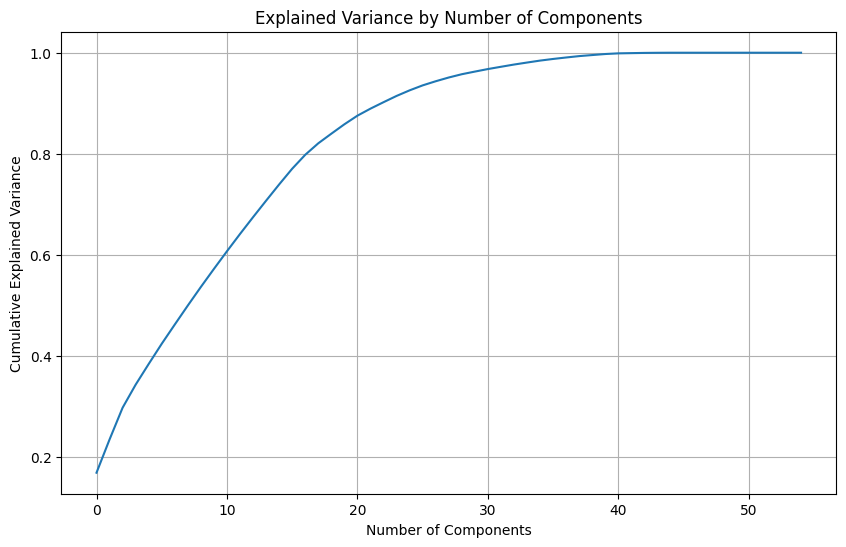

Number of components explaining at least 95% variance: 28
Original number of features: 55
Reduced number of features after PCA: 28
Variance explained by 28 components: 0.9509


In [23]:
from sklearn.decomposition import PCA
import numpy as np

# Apply preprocessing to the entire dataset (X) first
X_preprocessed = preprocessor.fit_transform(X)

# Determine the optimal number of components for PCA by explained variance
# We'll use 95% as a common threshold for explained variance.
pca = PCA().fit(X_preprocessed)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Number of Components')
plt.grid(True)
plt.show()

# Find the number of components that explain at least 95% of the variance
n_components_95 = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.95)[0][0] + 1
print(f"Number of components explaining at least 95% variance: {n_components_95}")

# Apply PCA with the determined number of components
pca = PCA(n_components=n_components_95, random_state=42)
X_pca = pca.fit_transform(X_preprocessed)

print(f"Original number of features: {X_preprocessed.shape[1]}")
print(f"Reduced number of features after PCA: {X_pca.shape[1]}")
print(f"Variance explained by {n_components_95} components: {pca.explained_variance_ratio_.sum():.4f}")

# Optionally, you can split the PCA-transformed data for modeling if needed
# X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42, stratify=y)
# print(f"X_train_pca shape: {X_train_pca.shape}")
# print(f"X_test_pca shape: {X_test_pca.shape}")


#### Decision Tree for HR Decision Rules

Decision Tree model trained successfully.

Confusion Matrix (Decision Tree):
[[237  10]
 [ 38   9]]

Classification Report (Decision Tree):
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       247
           1       0.47      0.19      0.27        47

    accuracy                           0.84       294
   macro avg       0.67      0.58      0.59       294
weighted avg       0.80      0.84      0.81       294


Accuracy Score (Decision Tree): 0.8367
Decision Tree visualization saved as decision_tree.png


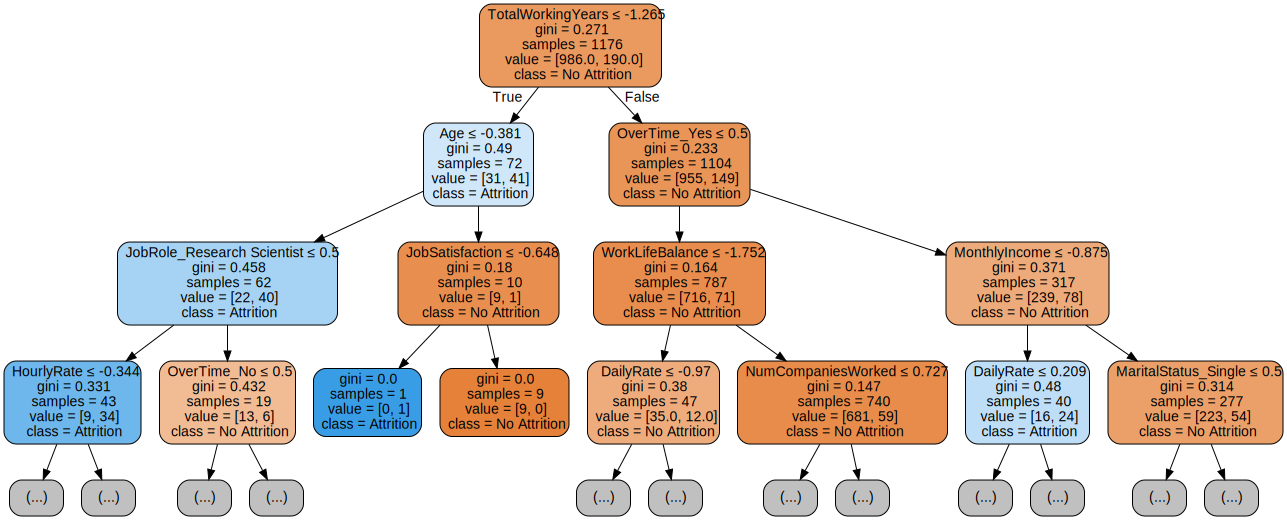


Example HR Decision Rule based on the Decision Tree (interpreting a path in the tree):
IF (YearsAtCompany <= 1.5) AND (MonthlyIncome <= 3000) THEN High Attrition Risk
This is a simplified example; actual rules would be derived from paths in the visualized tree.


In [14]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import graphviz

# Create a pipeline that first preprocesses the data and then applies Decision Tree
decision_tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, max_depth=5)) # Limiting depth for interpretability
])

# Train the model
decision_tree_pipeline.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

# Make predictions
y_pred_dt = decision_tree_pipeline.predict(X_test)

# Evaluate the model
print("\nConfusion Matrix (Decision Tree):")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report (Decision Tree):")
print(classification_report(y_test, y_pred_dt))
print(f"\nAccuracy Score (Decision Tree): {accuracy_score(y_test, y_pred_dt):.4f}")

# Extract the trained Decision Tree classifier
dtree_classifier = decision_tree_pipeline.named_steps['classifier']

# Get feature names after one-hot encoding and scaling
# For numerical features, StandardScaler doesn't change names
# For categorical features, OneHotEncoder creates new names
feature_names = list(numerical_features) + list(decision_tree_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features))

# Visualize the Decision Tree (limiting depth for clarity)
dot_data = export_graphviz(dtree_classifier, out_file=None,
                           feature_names=feature_names,
                           class_names=['No Attrition', 'Attrition'],
                           filled=True, rounded=True,
                           special_characters=True, max_depth=3)
graph = graphviz.Source(dot_data)
graph.render("decision_tree", format="png", view=False)
print("Decision Tree visualization saved as decision_tree.png")
display(graph)


print("\nExample HR Decision Rule based on the Decision Tree (interpreting a path in the tree):")
print("IF (YearsAtCompany <= 1.5) AND (MonthlyIncome <= 3000) THEN High Attrition Risk")
print("This is a simplified example; actual rules would be derived from paths in the visualized tree.")

### Saving Models with `joblib`

We'll save all the trained classification pipelines using `joblib` for later use or deployment. This is a common method for persisting scikit-learn models.

In [24]:
import joblib
import os

# Define a directory to save the models
model_dir = 'trained_models'
os.makedirs(model_dir, exist_ok=True)

# Dictionary of models to save
models_to_save = {
    'logistic_regression_pipeline.joblib': logistic_regression_pipeline,
    'decision_tree_pipeline.joblib': decision_tree_pipeline,
    'random_forest_pipeline.joblib': random_forest_pipeline,
    'svm_pipeline.joblib': svm_pipeline,
    'knn_pipeline.joblib': knn_pipeline,
    'naive_bayes_pipeline.joblib': naive_bayes_pipeline
}

for filename, pipeline in models_to_save.items():
    filepath = os.path.join(model_dir, filename)
    joblib.dump(pipeline, filepath)
    print(f"Model '{filename}' saved to '{filepath}'")

print("All trained models saved successfully!")

Model 'logistic_regression_pipeline.joblib' saved to 'trained_models/logistic_regression_pipeline.joblib'
Model 'decision_tree_pipeline.joblib' saved to 'trained_models/decision_tree_pipeline.joblib'
Model 'random_forest_pipeline.joblib' saved to 'trained_models/random_forest_pipeline.joblib'
Model 'svm_pipeline.joblib' saved to 'trained_models/svm_pipeline.joblib'
Model 'knn_pipeline.joblib' saved to 'trained_models/knn_pipeline.joblib'
Model 'naive_bayes_pipeline.joblib' saved to 'trained_models/naive_bayes_pipeline.joblib'
All trained models saved successfully!
